**Implement an End to End CNN Model for Image Classification Task.**

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip'
data_path = '/content/drive/MyDrive/AI ML/Data'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip' to '/content/drive/MyDrive/AI ML'


**Task 1: Data Understanding and Visualization:**

1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

In [190]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [191]:
train_dir = '/content/drive/MyDrive/AI ML/FruitinAmazon/train'
classes = sorted(os.listdir(train_dir))
print(f"Classes found: {classes}")

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


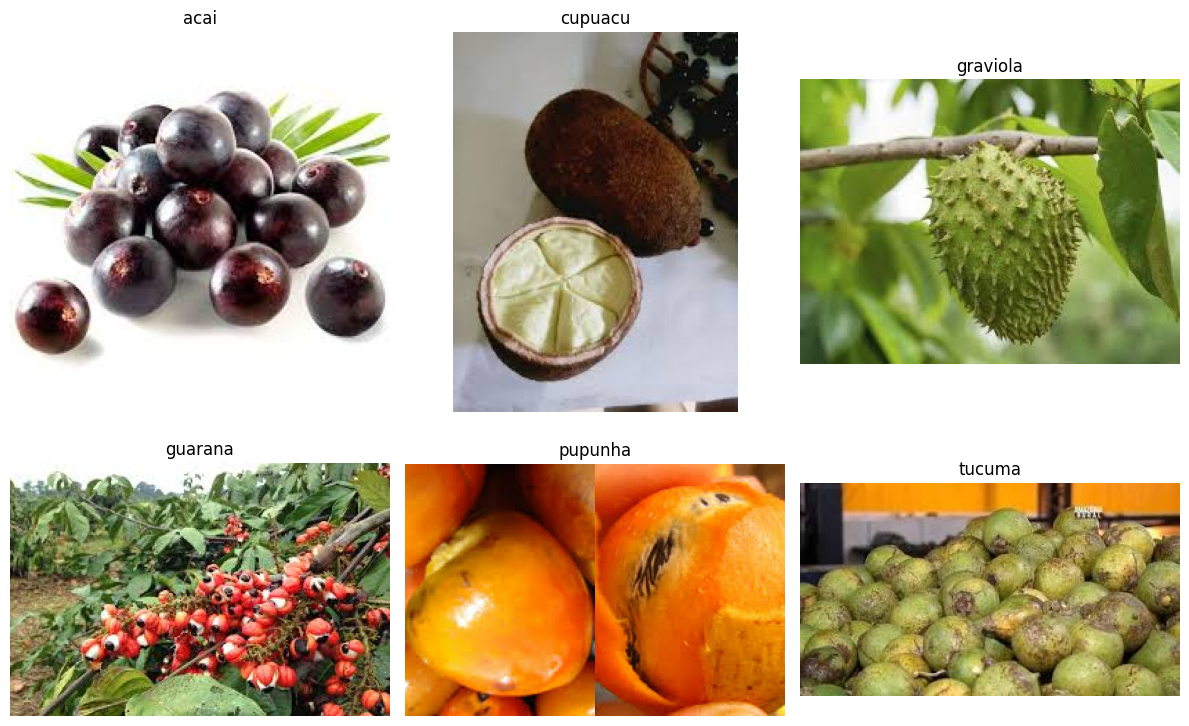

In [192]:
plt.figure(figsize=(12, 8))
for i, category in enumerate(classes):
    class_path = os.path.join(train_dir, category)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [193]:
corrupted_images = []

for category in classes:
    class_path = os.path.join(train_dir, category)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            os.remove(img_path)
            corrupted_images.append(img_path)

if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


**Task 2: Loading and Preprocessing Image Data in keras:**

In [194]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32

rescale = tf.keras.layers.Rescaling(1./255)

# Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Store the class names properly
my_class_names = train_ds.class_names

# Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Task 3 - Implement a CNN **

In [195]:
from tensorflow.keras import layers, models

# Augmentation layer to help with small dataset accuracy
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    # Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3 (Added for better feature extraction)
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Prevents overfitting
    layers.Dense(64, activation='relu'),
    layers.Dense(len(my_class_names), activation='softmax')
])

**Task 4: Compile the Model**

In [196]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [197]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_fruit_model.h5', save_best_only=True)
]

**Task 4: Train the Model**

In [198]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.1950 - loss: 1.7997

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1944 - loss: 1.8006 - val_accuracy: 0.2222 - val_loss: 1.8815
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 891ms/step - accuracy: 0.1528 - loss: 1.8212 - val_accuracy: 0.0556 - val_loss: 1.8870
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.2101 - loss: 1.7897

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2083 - loss: 1.7710 - val_accuracy: 0.0556 - val_loss: 1.8747
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.2650 - loss: 1.7222

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 935ms/step - accuracy: 0.2639 - loss: 1.7108 - val_accuracy: 0.0556 - val_loss: 1.8735
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.2442 - loss: 1.6552

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 987ms/step - accuracy: 0.2639 - loss: 1.6422 - val_accuracy: 0.1111 - val_loss: 1.8287
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.2992 - loss: 1.6629

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4167 - loss: 1.4393 - val_accuracy: 0.3889 - val_loss: 1.6532
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 871ms/step - accuracy: 0.4722 - loss: 1.3770 - val_accuracy: 0.3333 - val_loss: 1.7697
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5816 - loss: 1.1707

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5417 - loss: 1.2172 - val_accuracy: 0.3333 - val_loss: 1.4443
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 864ms/step - accuracy: 0.4583 - loss: 1.2888 - val_accuracy: 0.4444 - val_loss: 1.5179
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5833 - loss: 1.0823 - val_accuracy: 0.2778 - val_loss: 2.0852
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5694 - loss: 1.0962

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5833 - loss: 1.0529 - val_accuracy: 0.5000 - val_loss: 1.4181
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.6956 - loss: 0.9925

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6806 - loss: 0.9682 - val_accuracy: 0.6111 - val_loss: 1.2757
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 849ms/step - accuracy: 0.6944 - loss: 0.8789 - val_accuracy: 0.4444 - val_loss: 1.4829
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6944 - loss: 0.7690 - val_accuracy: 0.5000 - val_loss: 1.6867
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 905ms/step - accuracy: 0.6111 - loss: 1.0059 - val_accuracy: 0.4444 - val_loss: 1.4858
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.6950 - loss: 0.7562

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 997ms/step - accuracy: 0.6944 - loss: 0.8171 - val_accuracy: 0.6111 - val_loss: 1.2281
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 946ms/step - accuracy: 0.6806 - loss: 0.7463 - val_accuracy: 0.6667 - val_loss: 1.2453
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7222 - loss: 0.7238 - val_accuracy: 0.5000 - val_loss: 1.4894
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 957ms/step - accuracy: 0.7222 - loss: 0.7367 - val_accuracy: 0.5556 - val_loss: 1.4994
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 812ms/step - accuracy: 0.8333 - loss: 0.5577 - val_accuracy: 0.5000 - val_loss: 1.4342
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8194 - loss: 0.5179 - val_accuracy: 0.5000 - val_loss: 1.5487
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7500 - loss: 0.5639 - val_accuracy: 0.4444 - val_loss: 1.7575
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 915ms/step - accuracy: 0.7778 - loss: 0.4988 - val_accuracy: 0.5000 - val_loss: 1.767

**Task 5: Evaluate the Model**

In [199]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6111 - loss: 1.2281
Validation Accuracy: 0.6111


**Task 6: Save and Load the Model**

In [200]:
model.save('final_fruit_model.keras')
loaded_model = tf.keras.models.load_model('final_fruit_model.keras')
print("Model saved and re-loaded successfully.")

Model saved and re-loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


**Task 7: Predictions and Classification Report**

In [201]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

# Make predictions on the validation set
for images, labels in val_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Dynamically handle names to avoid ValueError
unique_labels = np.unique(y_true)
target_names = [my_class_names[i] for i in unique_labels]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         1
     cupuacu       0.50      0.50      0.50         2
    graviola       0.67      0.67      0.67         3
     guarana       0.62      1.00      0.77         5
     pupunha       0.33      0.25      0.29         4
      tucuma       1.00      0.33      0.50         3

    accuracy                           0.61        18
   macro avg       0.69      0.62      0.62        18
weighted avg       0.64      0.61      0.58        18



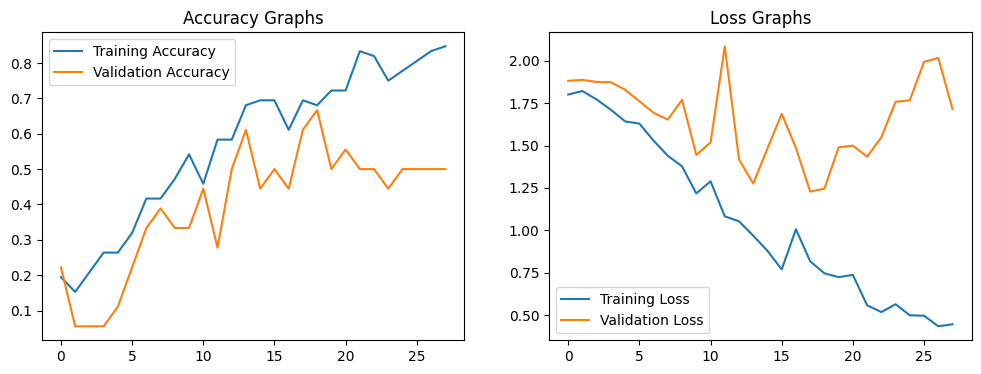

In [202]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graphs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graphs')
plt.legend()
plt.show()